# NB03: Antibiotic Validation (Positive Control)

Test H4: AMR genes should show *negative* fitness under matching antibiotic conditions
(demonstrating they are genuinely protective when needed).

**Approach:**
1. Class-matched validation: beta-lactam genes × carbenicillin, aminoglycoside genes × gentamicin, etc.
2. Any-antibiotic validation: all AMR genes under any antibiotic experiment
3. Fitness flip: paired comparison of same genes under antibiotic vs non-antibiotic conditions

**Inputs:** `data/amr_fitness_noabx.csv`, `data/experiment_classification.csv`, fitness matrices

**Outputs:** `data/amr_fitness_abx_validation.csv`, figures

In [1]:
import os
import warnings
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_fitness_cost')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_fitness_cost')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
FM_DATA = os.path.join(REPO, 'projects', 'fitness_modules', 'data')

# Load NB02 outputs
gene_noabx = pd.read_csv(os.path.join(DATA, 'amr_fitness_noabx.csv'))
exps = pd.read_csv(os.path.join(DATA, 'experiment_classification.csv'))
amr = pd.read_csv(os.path.join(DATA, 'amr_genes_fb.csv'))

print(f'AMR genes with non-abx fitness: {len(gene_noabx)}')
print(f'Antibiotic experiments: {(exps["exp_category"] == "antibiotic").sum()}')

AMR genes with non-abx fitness: 801
Antibiotic experiments: 443


## 1. Class-matched antibiotic validation

In [2]:
# Define AMR class -> antibiotic class mapping
AMR_ABX_MATCH = {
    'beta_lactam': 'beta_lactam',
    'aminoglycoside': 'aminoglycoside',
    'chloramphenicol': 'chloramphenicol',
    'tetracycline': 'tetracycline',
}

abx_exps = exps[exps['exp_category'] == 'antibiotic']

# For each testable class, compute AMR gene fitness under matching antibiotic
all_abx_results = []

for amr_class, abx_class in AMR_ABX_MATCH.items():
    class_exps = abx_exps[abx_exps['antibiotic_class'] == abx_class]
    class_genes = gene_noabx[gene_noabx['amr_class'] == amr_class]
    
    # Find organisms with both
    orgs_with_exps = set(class_exps['orgId'])
    orgs_with_genes = set(class_genes['orgId'])
    orgs_both = sorted(orgs_with_exps & orgs_with_genes)
    
    if not orgs_both:
        continue
    
    print(f'\n=== {amr_class} x {abx_class}: {len(orgs_both)} organisms ===')
    
    for org in orgs_both:
        mat_path = os.path.join(FM_DATA, 'matrices', f'{org}_fitness_matrix.csv')
        if not os.path.exists(mat_path):
            continue
        fit_mat = pd.read_csv(mat_path, index_col=0)
        fit_mat.index = fit_mat.index.astype(str)
        fit_mat = fit_mat.apply(pd.to_numeric, errors='coerce')
        
        # Get antibiotic experiment columns
        org_abx_exps = class_exps[class_exps['orgId'] == org]['expName'].tolist()
        avail_abx = [e for e in org_abx_exps if e in fit_mat.columns]
        if not avail_abx:
            continue
        
        # Get AMR genes for this class in this organism
        org_genes = class_genes[class_genes['orgId'] == org]
        amr_loci = [str(l) for l in org_genes['locusId'] if str(l) in fit_mat.index]
        if not amr_loci:
            continue
        
        non_amr_loci = [l for l in fit_mat.index if l not in set(str(x) for x in amr['locusId'][amr['orgId'] == org])]
        
        # Fitness under matching antibiotic
        amr_abx_fitness = fit_mat.loc[amr_loci, avail_abx].mean(axis=1)
        bg_abx_fitness = fit_mat.loc[non_amr_loci, avail_abx].mean(axis=1)
        
        for locus in amr_loci:
            noabx_row = gene_noabx[(gene_noabx['orgId'] == org) & 
                                    (gene_noabx['locusId'] == locus)]
            noabx_fit = noabx_row['mean_fitness'].values[0] if len(noabx_row) > 0 else np.nan
            
            all_abx_results.append({
                'orgId': org,
                'locusId': locus,
                'amr_class': amr_class,
                'abx_class': abx_class,
                'match_type': 'class_matched',
                'fitness_abx': amr_abx_fitness[locus],
                'fitness_noabx': noabx_fit,
                'fitness_flip': noabx_fit - amr_abx_fitness[locus],
                'n_abx_exps': len(avail_abx),
            })
        
        print(f'  {org}: {len(amr_loci)} genes, {len(avail_abx)} abx exps, '
              f'AMR abx mean={amr_abx_fitness.mean():+.3f}, bg abx mean={bg_abx_fitness.mean():+.3f}')

abx_df = pd.DataFrame(all_abx_results)
print(f'\nTotal class-matched gene-antibiotic pairs: {len(abx_df)}')


=== beta_lactam x beta_lactam: 10 organisms ===


  Btheta: 9 genes, 6 abx exps, AMR abx mean=+0.031, bg abx mean=-0.073


  Caulo: 18 genes, 4 abx exps, AMR abx mean=-0.304, bg abx mean=+0.060


  DvH: 6 genes, 3 abx exps, AMR abx mean=-0.002, bg abx mean=-0.041


  Korea: 18 genes, 1 abx exps, AMR abx mean=-0.044, bg abx mean=-0.017


...

  Btheta: 3 genes, 18 abx exps, AMR abx mean=+0.077, bg abx mean=-0.084


  Caulo: 1 genes, 4 abx exps, AMR abx mean=-0.122, bg abx mean=+0.043


  Phaeo: 1 genes, 1 abx exps, AMR abx mean=-0.337, bg abx mean=-0.051


  WCS417: 1 genes, 1 abx exps, AMR abx mean=+0.028, bg abx mean=-0.041


  pseudo5_N2C3_1: 1 genes, 1 abx exps, AMR abx mean=-0.474, bg abx mean=-0.045

Total class-matched gene-antibiotic pairs: 157


## 2. Any-antibiotic validation

Test all AMR genes (regardless of class) under any antibiotic experiment in their organism.

In [3]:
# For every AMR gene in gene_noabx, also compute fitness under ALL antibiotic exps
any_abx_results = []

for org in gene_noabx['orgId'].unique():
    org_abx = abx_exps[abx_exps['orgId'] == org]
    if len(org_abx) == 0:
        continue
    
    mat_path = os.path.join(FM_DATA, 'matrices', f'{org}_fitness_matrix.csv')
    if not os.path.exists(mat_path):
        continue
    fit_mat = pd.read_csv(mat_path, index_col=0)
    fit_mat.index = fit_mat.index.astype(str)
    fit_mat = fit_mat.apply(pd.to_numeric, errors='coerce')
    
    avail_abx = [e for e in org_abx['expName'] if e in fit_mat.columns]
    if not avail_abx:
        continue
    
    org_genes = gene_noabx[gene_noabx['orgId'] == org]
    for _, row in org_genes.iterrows():
        locus = str(row['locusId'])
        if locus not in fit_mat.index:
            continue
        
        abx_fit = fit_mat.loc[locus, avail_abx].mean()
        any_abx_results.append({
            'orgId': org,
            'locusId': locus,
            'amr_class': row['amr_class'],
            'amr_mechanism': row['amr_mechanism'],
            'match_type': 'any_antibiotic',
            'fitness_abx': abx_fit,
            'fitness_noabx': row['mean_fitness'],
            'fitness_flip': row['mean_fitness'] - abx_fit,
            'n_abx_exps': len(avail_abx),
            'amr_tier': row['amr_tier'],
        })

any_abx_df = pd.DataFrame(any_abx_results)
print(f'AMR genes with any-antibiotic fitness: {len(any_abx_df)}')
print(f'Organisms: {any_abx_df["orgId"].nunique()}')

AMR genes with any-antibiotic fitness: 797
Organisms: 26


## 3. Fitness flip analysis

In [4]:
# Class-matched: do AMR genes show a fitness flip (positive without abx -> negative with abx)?
print('=== Class-Matched Fitness Flip ===')
if len(abx_df) > 0:
    valid = abx_df.dropna(subset=['fitness_noabx', 'fitness_abx'])
    print(f'Valid pairs: {len(valid)}')
    print(f'Mean fitness without antibiotic: {valid["fitness_noabx"].mean():+.4f}')
    print(f'Mean fitness with antibiotic:    {valid["fitness_abx"].mean():+.4f}')
    print(f'Mean flip (noabx - abx):         {valid["fitness_flip"].mean():+.4f}')
    
    # Wilcoxon signed-rank: is the flip > 0? (genes more beneficial under abx)
    if len(valid) >= 5:
        w_stat, w_p = stats.wilcoxon(valid['fitness_flip'], alternative='greater')
        print(f'Wilcoxon signed-rank (flip > 0): p={w_p:.4g}')
    
    # What fraction show the expected direction?
    n_protective = (valid['fitness_abx'] < valid['fitness_noabx']).sum()
    print(f'Genes more important under abx: {n_protective}/{len(valid)} '
          f'({n_protective/len(valid)*100:.1f}%)')
    
    # By class
    print(f'\nPer-class breakdown:')
    for cls in valid['amr_class'].unique():
        sub = valid[valid['amr_class'] == cls]
        n_prot = (sub['fitness_abx'] < sub['fitness_noabx']).sum()
        print(f'  {cls:25s}: {len(sub):3d} genes, flip={sub["fitness_flip"].mean():+.4f}, '
              f'{n_prot}/{len(sub)} protective ({n_prot/len(sub)*100:.0f}%)')
else:
    print('No class-matched pairs available.')

=== Class-Matched Fitness Flip ===
Valid pairs: 157
Mean fitness without antibiotic: -0.0435
Mean fitness with antibiotic:    -0.1568
Mean flip (noabx - abx):         +0.1134
Wilcoxon signed-rank (flip > 0): p=0.1365
Genes more important under abx: 86/157 (54.8%)

Per-class breakdown:
  beta_lactam              : 105 genes, flip=+0.1474, 53/105 protective (50%)
  aminoglycoside           :  39 genes, flip=+0.0311, 24/39 protective (62%)
  chloramphenicol          :   6 genes, flip=+0.1235, 6/6 protective (100%)
  tetracycline             :   7 genes, flip=+0.0515, 3/7 protective (43%)


In [5]:
# Any-antibiotic fitness flip
print('=== Any-Antibiotic Fitness Flip ===')
valid_any = any_abx_df.dropna(subset=['fitness_noabx', 'fitness_abx'])
print(f'Valid pairs: {len(valid_any)}')
print(f'Mean fitness without antibiotic: {valid_any["fitness_noabx"].mean():+.4f}')
print(f'Mean fitness with antibiotic:    {valid_any["fitness_abx"].mean():+.4f}')
print(f'Mean flip (noabx - abx):         {valid_any["fitness_flip"].mean():+.4f}')

w_stat, w_p = stats.wilcoxon(valid_any['fitness_flip'], alternative='greater')
print(f'Wilcoxon signed-rank (flip > 0): p={w_p:.4g}')

n_protective = (valid_any['fitness_abx'] < valid_any['fitness_noabx']).sum()
print(f'Genes more important under abx: {n_protective}/{len(valid_any)} '
      f'({n_protective/len(valid_any)*100:.1f}%)')

# By mechanism
print(f'\nPer-mechanism breakdown:')
for mech in valid_any['amr_mechanism'].value_counts().index:
    sub = valid_any[valid_any['amr_mechanism'] == mech]
    n_prot = (sub['fitness_abx'] < sub['fitness_noabx']).sum()
    print(f'  {mech:25s}: {len(sub):3d} genes, flip={sub["fitness_flip"].mean():+.4f}, '
          f'{n_prot}/{len(sub)} protective ({n_prot/len(sub)*100:.0f}%)')

=== Any-Antibiotic Fitness Flip ===
Valid pairs: 797
Mean fitness without antibiotic: -0.0242
Mean fitness with antibiotic:    -0.0692
Mean flip (noabx - abx):         +0.0451
Wilcoxon signed-rank (flip > 0): p=0.0001078
Genes more important under abx: 454/797 (57.0%)

Per-mechanism breakdown:
  enzymatic_inactivation   : 302 genes, flip=-0.0007, 168/302 protective (56%)
  efflux                   : 252 genes, flip=+0.0942, 155/252 protective (62%)
  metal_resistance         : 144 genes, flip=+0.0254, 72/144 protective (50%)
  unknown                  :  74 genes, flip=+0.1273, 45/74 protective (61%)
  target_modification      :   7 genes, flip=-0.0151, 3/7 protective (43%)
  other                    :   1 genes, flip=+0.1657, 1/1 protective (100%)


## 4. Figures

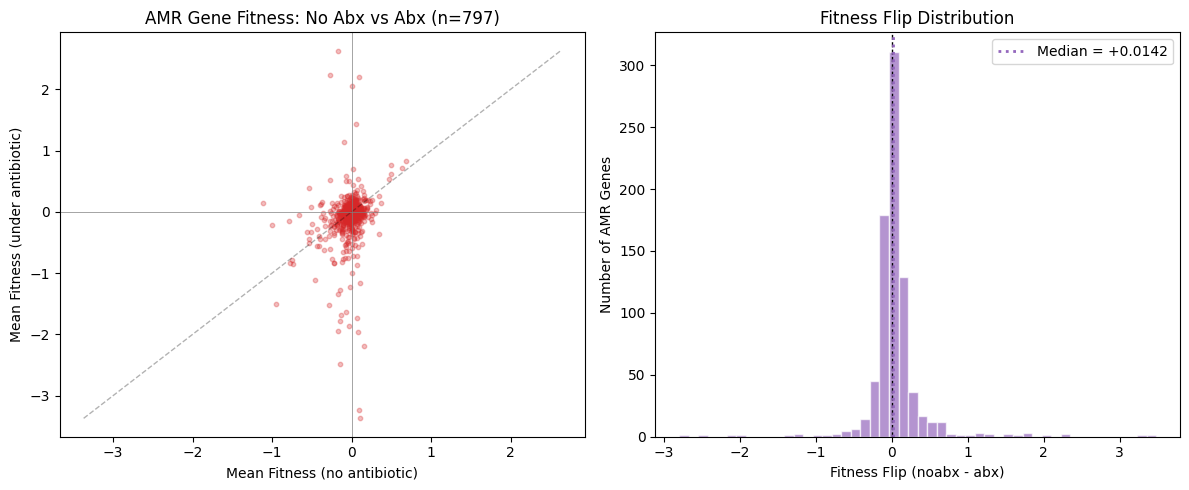

Saved to figures/antibiotic_validation.png


In [6]:
# Paired fitness plot: no-antibiotic vs antibiotic for any-antibiotic set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter of noabx vs abx fitness
ax = axes[0]
ax.scatter(valid_any['fitness_noabx'], valid_any['fitness_abx'],
           alpha=0.3, s=10, c='tab:red')
lims = [min(valid_any[['fitness_noabx', 'fitness_abx']].min()),
        max(valid_any[['fitness_noabx', 'fitness_abx']].max())]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Mean Fitness (no antibiotic)')
ax.set_ylabel('Mean Fitness (under antibiotic)')
ax.set_title(f'AMR Gene Fitness: No Abx vs Abx (n={len(valid_any)})')

# Right: distribution of fitness flip
ax = axes[1]
ax.hist(valid_any['fitness_flip'], bins=50, alpha=0.7, color='tab:purple', edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(valid_any['fitness_flip'].median(), color='tab:purple', linestyle=':', linewidth=2,
           label=f'Median = {valid_any["fitness_flip"].median():+.4f}')
ax.set_xlabel('Fitness Flip (noabx - abx)')
ax.set_ylabel('Number of AMR Genes')
ax.set_title('Fitness Flip Distribution')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'antibiotic_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/antibiotic_validation.png')

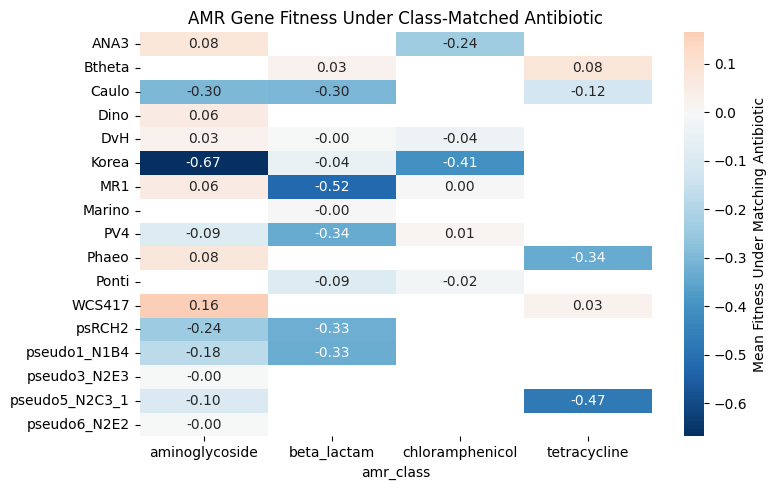

Saved to figures/class_matched_heatmap.png


In [7]:
# Class-matched heatmap: per-class, per-organism mean fitness under matching abx
if len(abx_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    pivot = abx_df.groupby(['orgId', 'amr_class'])['fitness_abx'].mean().unstack()
    # Only show organisms with data
    pivot = pivot.dropna(how='all')
    
    sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                ax=ax, cbar_kws={'label': 'Mean Fitness Under Matching Antibiotic'})
    ax.set_title('AMR Gene Fitness Under Class-Matched Antibiotic')
    ax.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, 'class_matched_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to figures/class_matched_heatmap.png')

## 5. Save outputs

In [8]:
# Combine class-matched and any-abx results
all_validation = pd.concat([abx_df, any_abx_df], ignore_index=True)
all_validation.to_csv(os.path.join(DATA, 'amr_fitness_abx_validation.csv'), index=False)
print(f'Saved {len(all_validation)} validation records to data/amr_fitness_abx_validation.csv')

print(f'\n=== NB03 Summary ===')
if len(abx_df) > 0:
    valid_cm = abx_df.dropna(subset=['fitness_noabx', 'fitness_abx'])
    n_prot_cm = (valid_cm['fitness_abx'] < valid_cm['fitness_noabx']).sum()
    print(f'Class-matched: {len(valid_cm)} pairs, {n_prot_cm}/{len(valid_cm)} '
          f'({n_prot_cm/len(valid_cm)*100:.0f}%) show expected flip')

n_prot_any = (valid_any['fitness_abx'] < valid_any['fitness_noabx']).sum()
print(f'Any-antibiotic: {len(valid_any)} pairs, {n_prot_any}/{len(valid_any)} '
      f'({n_prot_any/len(valid_any)*100:.0f}%) show expected flip')

Saved 954 validation records to data/amr_fitness_abx_validation.csv

=== NB03 Summary ===
Class-matched: 157 pairs, 86/157 (55%) show expected flip
Any-antibiotic: 797 pairs, 454/797 (57%) show expected flip
